In [1]:
report_full = "../../output/zymo/ERR3152366.summary_identity_stats.csv"
report_isolates = "../../output/alignment_with_isolates/ERR3152366_vs_"

isolate_names = ["Listeria monocytogenes", 
                 "Pseudomonas aeruginosa",
                 "Bacillus subtilis",
                 "Saccharomyces cerevisiae",
                 "Escherichia coli",
                 "Salmonella enterica",
                 "Lactobacillus fermentum",

                 "Enterococcus faecalis",
                 "Cryptococcus neoformans",
                 "Staphylococcus aureus"]

isolate_genome_names = ["Listeria_monocytogenes_complete_genome", 
                 "Pseudomonas_aeruginosa_complete_genome",
                 "Bacillus_subtilis_complete_genome",
                 "Saccharomyces_cerevisiae_draft_genome",
                 "Escherichia_coli_complete_genome",
                 "Salmonella_enterica_complete_genome",
                 "Lactobacillus_fermentum_complete_genome",
                 "Enterococcus_faecalis_complete_genome",
                 "Cryptococcus_neoformans_draft_genome",
                 "Staphylococcus_aureus_complete_genome"]


theoretical_abundance = [0.891, 0.089, 0.0089, 0.0089, 0.00089, 0.00089, 0.000089, 0.0000089, 0.0000089, 0.00000089]

In [2]:
import pandas as pd

# Read the full report
full_report_df = pd.read_csv(report_full)
num_alignments_full = full_report_df["primary_alns"].item()
error_full = 1 - full_report_df["identity"].item()

In [3]:
error_rate_list = []
num_alignments_list = []


for i in range(len(isolate_names)):
    isolate_report_path = report_isolates + isolate_genome_names[i] + ".summary_identity_stats.csv"
    isolate_report_df = pd.read_csv(isolate_report_path)
    identity_isolate = isolate_report_df["identity"].item()
    num_alignments_isolate = isolate_report_df["primary_alns"].item()

    error_rate_list.append(1 - identity_isolate)
    num_alignments_list.append(num_alignments_isolate)
    

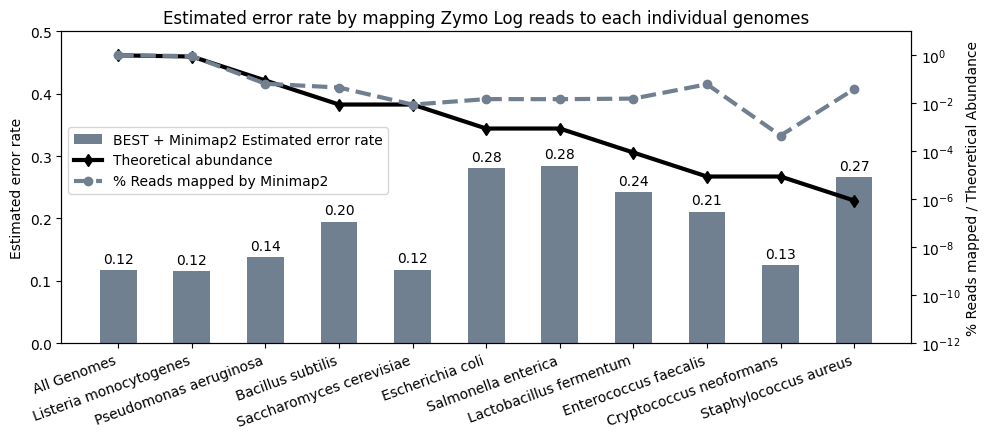

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the results: Bar plot of the identity for the full & each isolate, along with two line plots for the number of alignments (normalized by the total number of alignments) and theoretical abundance in log scale.
plt.rcParams['font.family'] = 'sans serif'
x = np.arange(len(isolate_names) + 1)  # the label locations
width = 0.5  # the width of the bars
fig, ax1 = plt.subplots(figsize=(10, 4.5))
bars = ax1.bar(x, [error_full] + error_rate_list, width, color='slategray', label='BEST + Minimap2 Estimated error rate')
ax1.set_ylabel('Estimated error rate')
ax1.set_xticks(x)
ax1.set_xticklabels(['All Genomes'] + isolate_names, rotation=20, ha='right')
ax1.tick_params(axis='y')
ax1.set_ylim(0, 0.5)
ax1.bar_label(bars, fmt='%.2f', padding=3)
ax1.set_title('Estimated error rate by mapping Zymo Log reads to each individual genomes')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
num_alignments_normalized = [n / num_alignments_full for n in num_alignments_list]

line2, = ax2.plot(x, [1.0] + theoretical_abundance, color='black', marker='d', linewidth=3, label='Theoretical abundance')
line1, = ax2.plot(x, [1.0] + num_alignments_normalized, color='slategray', marker='o', linestyle='--', linewidth=3, label='% Reads mapped by Minimap2')
ax2.set_ylabel('% Reads mapped / Theoretical Abundance')
ax2.set_yscale('log')
ax2.tick_params(axis='y')
ax2.set_ylim(1e-12, 10)
fig.legend(bbox_to_anchor=(0.4, 0.72))
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("../../figures/figure2_A.svg")